In [64]:
# Necessary libraries and useful parameters
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.sparse as sp
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

colors = ["#00274D", "#1B4F72", "#CFA6A6", "#CD5C5C", "#8B3A3A", "#641010"]
blue_red_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_map", colors)

In [65]:
# A 2D contour map of C
def contour_plot(Z, R, C, cmap=blue_red_cmap, cbar_label=r'$c/c_{\mathrm{max}}$'):
    contour = plt.contourf(Z, R, C, levels=200, cmap=cmap, vmax=1)
    cbar = plt.colorbar(contour, label=cbar_label)
    
    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')
    plt.savefig('a.pdf', format='pdf')
    plt.show()

In [66]:
# Model constants
R = 0.1   # tube radius [m]
L = 1   # tube length [m]
T = 100 # Characteristic time

# Scaled constants
E = 3   # electrical advection coefficient
U = 7    # velocity advection coefficient
D = 1    # diffusion coefficient
kA = 1 # Langmuir adsorption constant

domain = ((0, 1), (0, 1), (0, 1))
M, K = 200, 150
h, ht = 1/M, 1/K

z = np.linspace(domain[0][0], domain[0][1], M+1)
r = np.linspace(domain[1][0], domain[1][1], M+1)
t = np.linspace(domain[2][0], domain[2][1], K+1)

grid = (z, r)
ZZ, RR = np.meshgrid(z, r) 

# Scaled block matrix coefficients
delta = ht/h**2 * D
gamma = delta * (R/L)**2
xi = ht/h * D*(E-1)/r
vartheta = ht/h * U*(1-r**2)
omega = xi + vartheta + 2*(gamma + delta) + 1

In [67]:
def coeff_matrix(M:int) -> sp.csr_matrix:
    '''
    Create the block tridiagonal matrix A to solve AC^k+1 + g = -C^k.
    Input:
        M: number of grid points
    '''
    Z = M*(M-1)

    ll = np.repeat(delta + xi[1:-1], M)      # Lowest diag
    l = np.repeat(gamma + vartheta[1:-1], M) # Next lowest diag
    d = np.repeat(omega[1:-1], M)            # Main diag 
    u = np.full(Z, gamma)                    # Next highest diag
    uu = np.full(Z, delta)                   # Highest diag
    
    l[M-1::M], u[M-1::M] = 0, 0 # Every M'th element is zero in l and d
    
    A = sp.diags([ll, l, -d, u, uu], [-M, -1, 0, 1, M], (Z, Z), format='csr')

    return A

In [68]:
def boundary_vector(grid:tuple, k:int, qk:np.ndarray, Ck:np.ndarray, BC:tuple, M:int) -> np.ndarray:
  ''' 
  Create the boundary vector g to solve AC^k+1 + g = -C^k.
  Input:
    grid: (r, z) grids in r- and z directions
       k: the previous iteration step
      Ck: the previous concentration matrix
      BC: (g1, g2, g3) boundary condition functions
       M: number of grid points
  '''
  z, r = grid
  g1, g2, g3 = BC
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M))
  G[::-1, 0] += (gamma+vartheta[1:-1]) * g1(r[1:-1], t[k+1]) # Left contribution
  G[-1, :] += (delta+xi[1]) * g2(z[1:], t[k+1])              # Bottom contribution
  G[0, :] += delta * g3(qk[1:], Ck[-2, 1:])                   # Top contribution

  return G[::-1].ravel() # return G as a vector

In [69]:
def concentration_scheme(grid:tuple, A:np.ndarray, g:np.ndarray, k:int, qk:np.ndarray, Ck:np.ndarray, BC:tuple, M:int) -> np.ndarray:
    '''
    Calculate the next concentration matrix C^k+1.
    Input:
        grid: (r, z) grids in r- and z directions
           A: the coefficient matrix
           k: the previous iteration step
          Ck: the previous concentration matrix
           g: the boundary vector
          BC: (g1, g2, g3) boundary condition functions
           M: number of grid points
    '''
    z, r = grid
    g1, g2, g3 = BC
   
    C = np.zeros((M+1, M+1))
    C[::-1, 0] = g1(r, t[k+1]) # Left boundary
    C[-1, :] = g2(z, t[k+1])   # Bottom boundary  
    C[0, :] = g3(qk, Ck[-2, :]) # Top boundary

    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:][::-1].ravel()))
    C[1:-1, 1:] = np.reshape(C_interior, (M-1, M))
   
    return C

In [70]:
def RK4(f, q, params):
    ''' 
    Solve a set of ODE's using the RK4-method.
    Input:
             f: the right hand side of the differential equations. Here: The Langmuir model
             q: initial values
        params: parameters needed by f. Here: cwall
    Output:
             q: numerical solutions
    '''
    k1 = f(q, params)
    k2 = f(q+ht*k1/2, params)
    k3 = f(q+ht*k2/2, params)
    k4 = f(q+ht*k3, params)
    
    return q + h/6*(k1 + 2*(k2 + k3) + k4)

In [71]:
# Initial condition
def f(z, r):                   
    return np.zeros_like(ZZ)   
                                                         
# Boundary conditions
def i(r, t): # inlet
    return 1-r**2  

def e(z, t): # electric
    return 0

def langmuir(q, cwall): # RHS of langmuir model to be solved with RK4
    return kA*cwall*(1-q)
def d(qk, cwall): # deposition (discretized)
    return ((D/h) / ((D/h) - E/r[-1] - kA*(1-qk))) * cwall

<Figure size 640x480 with 0 Axes>

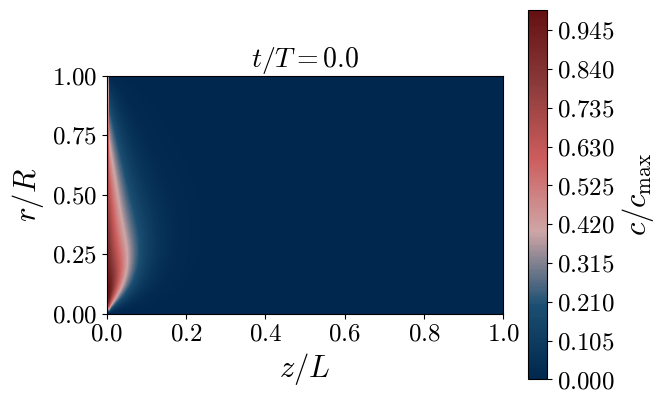

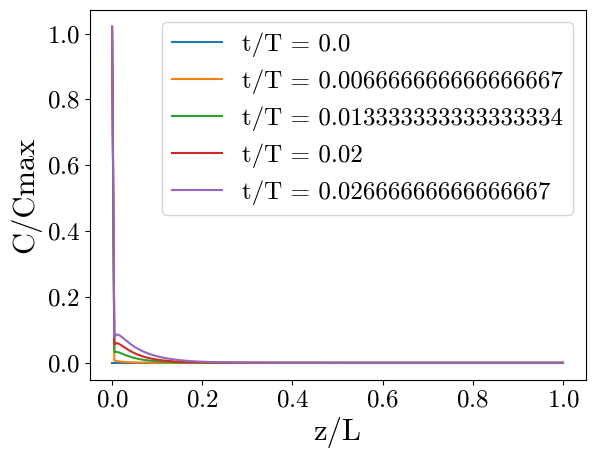

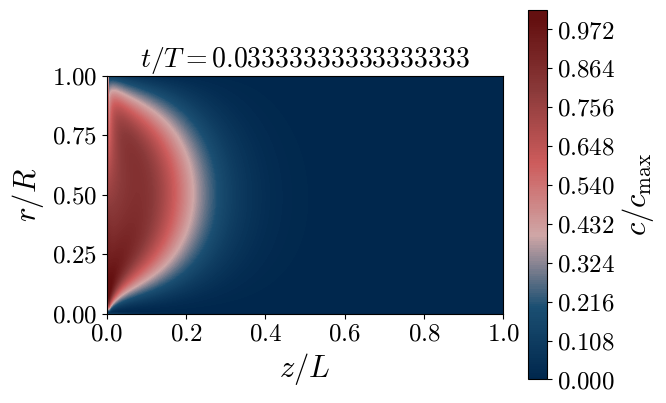

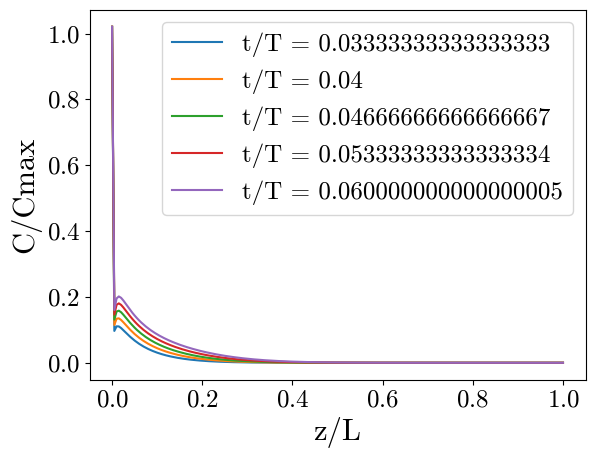

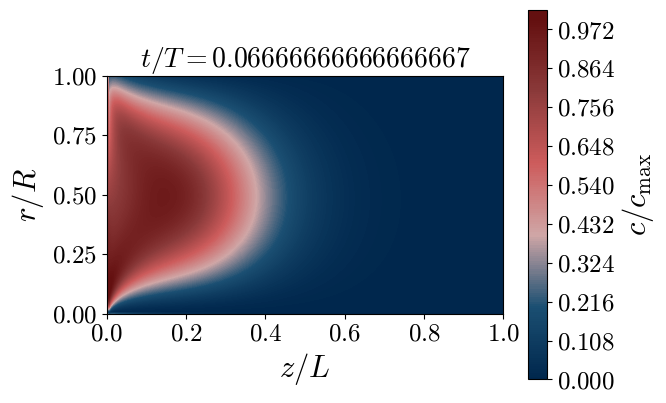

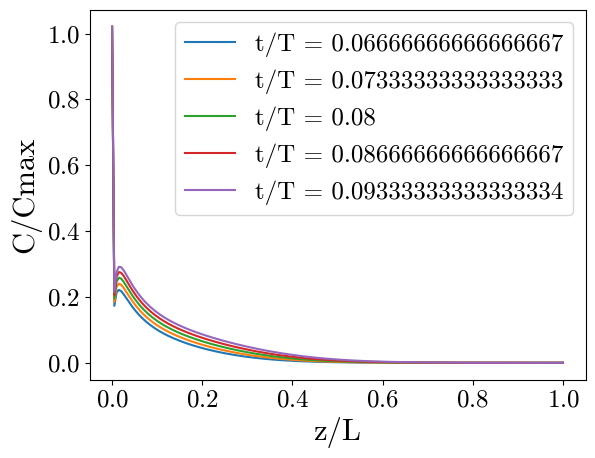

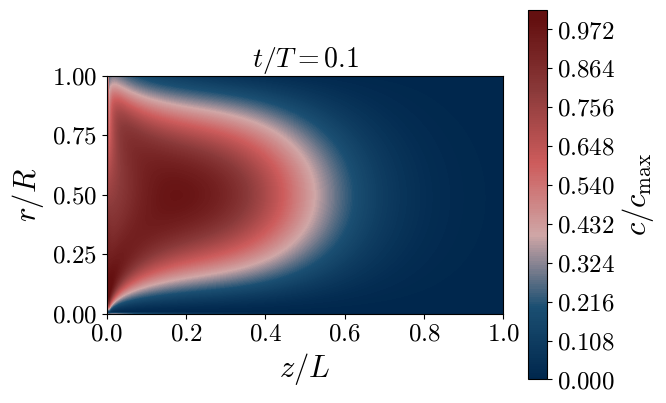

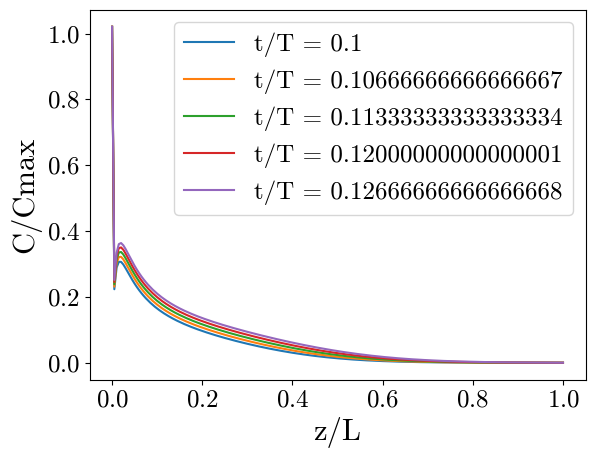

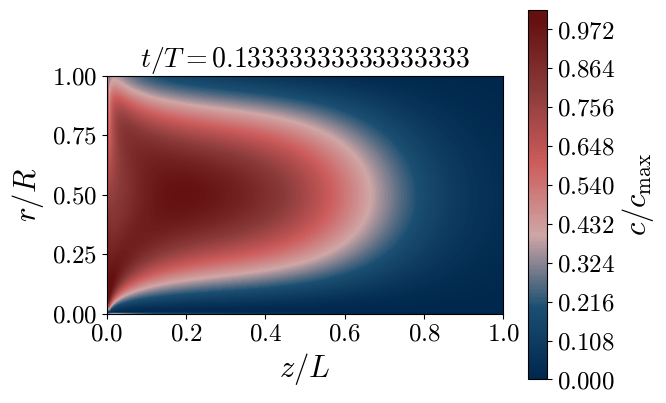

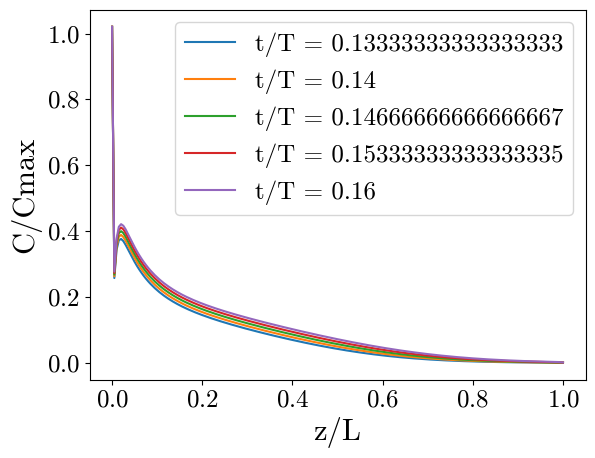

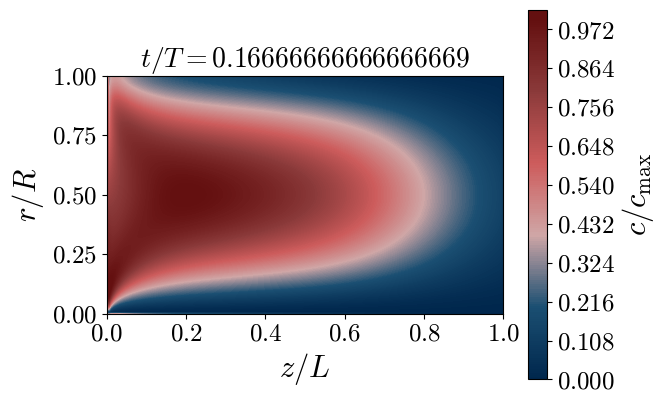

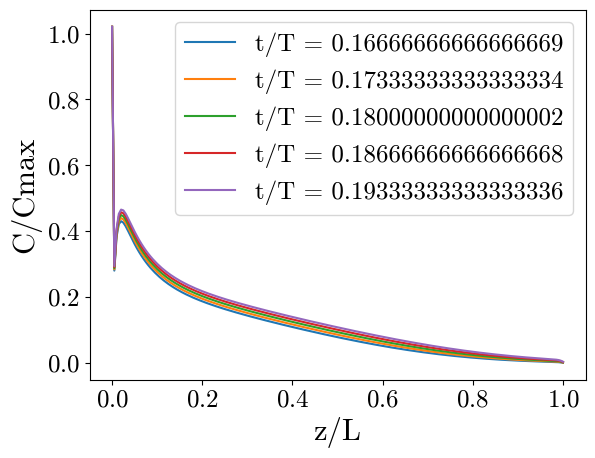

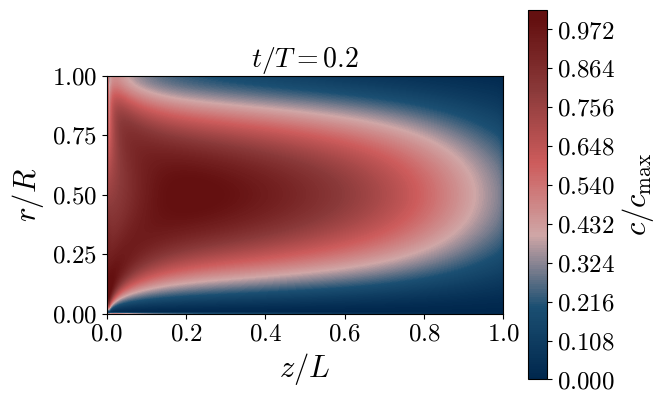

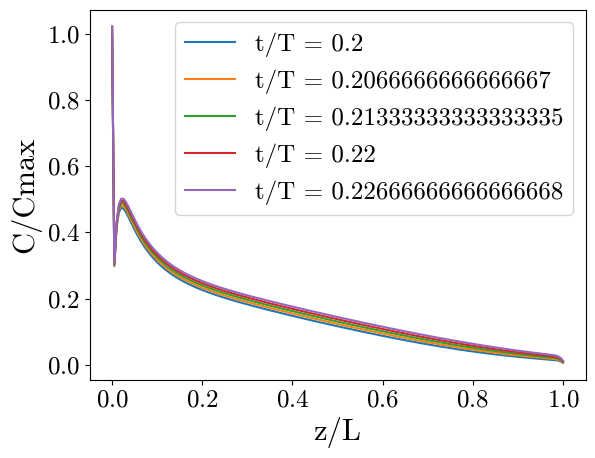

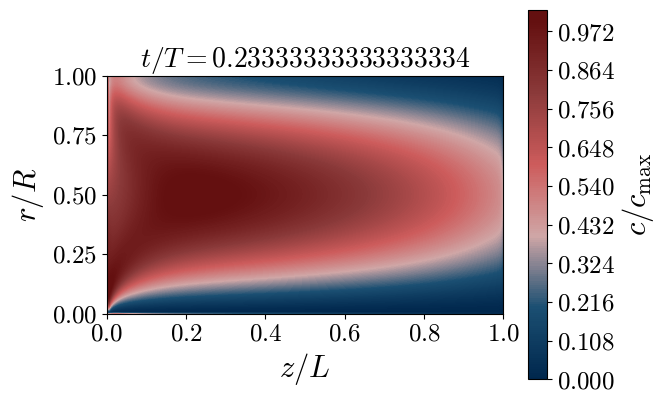

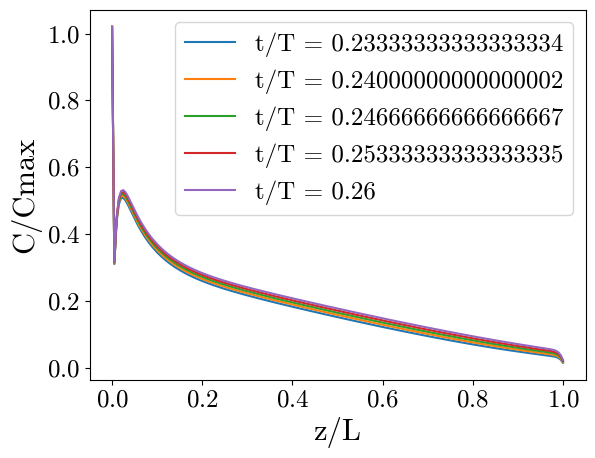

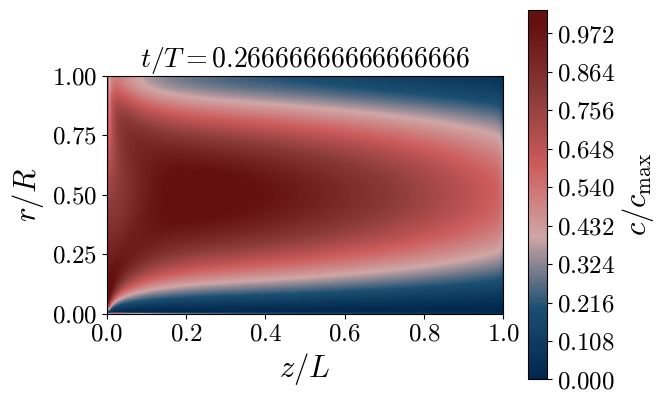

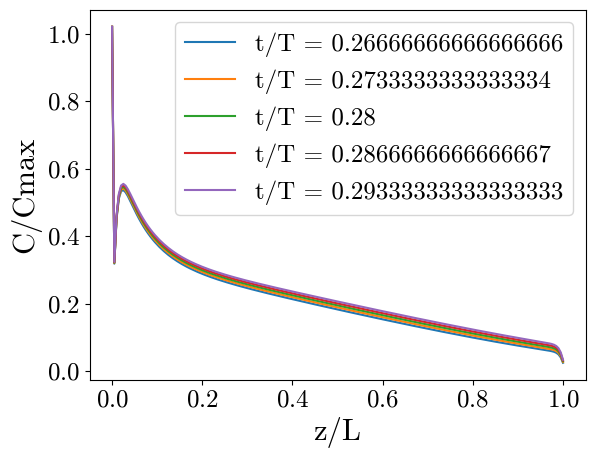

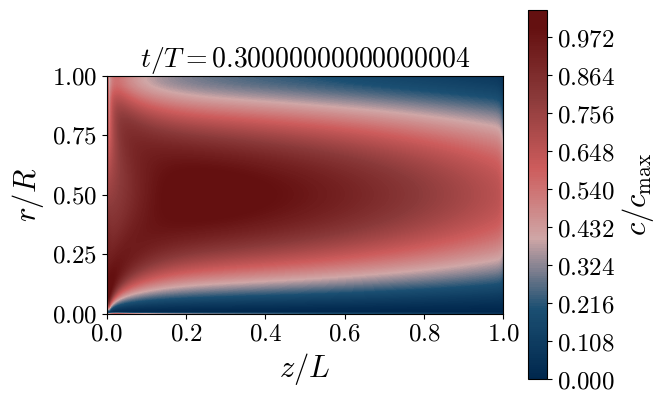

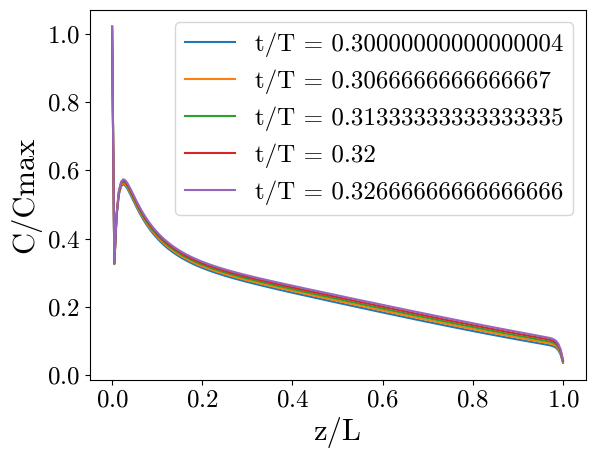

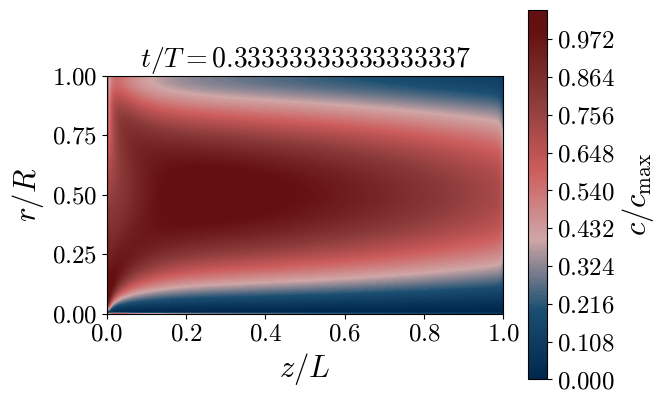

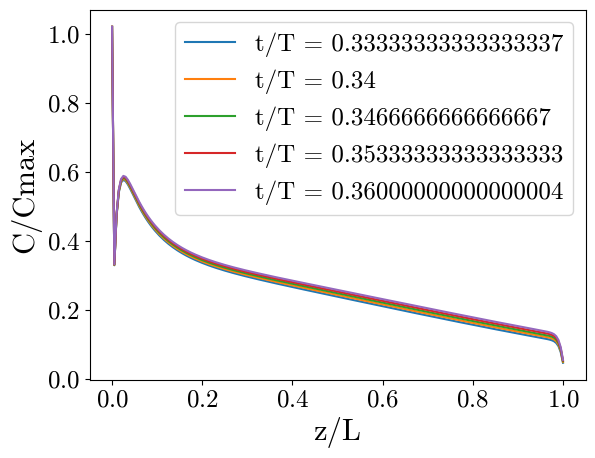

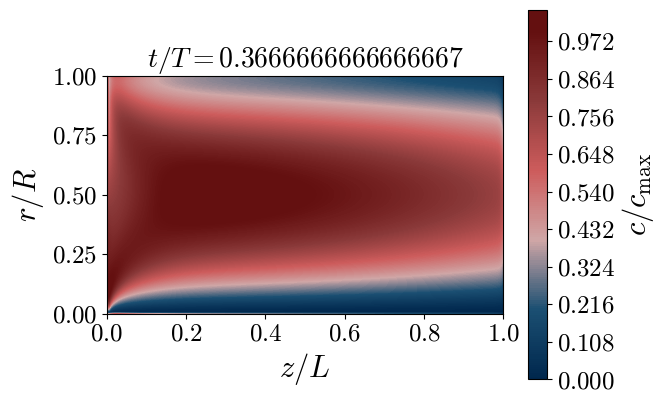

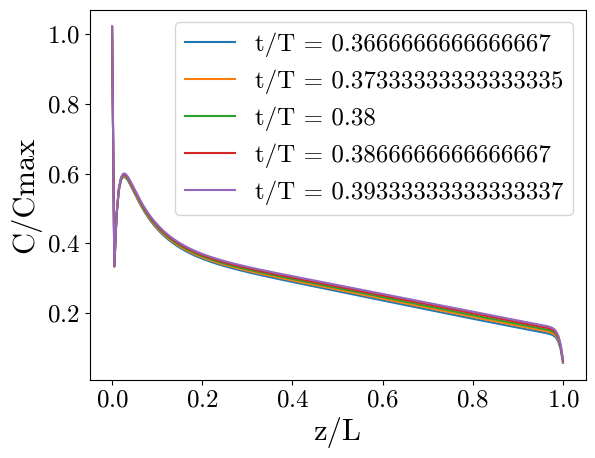

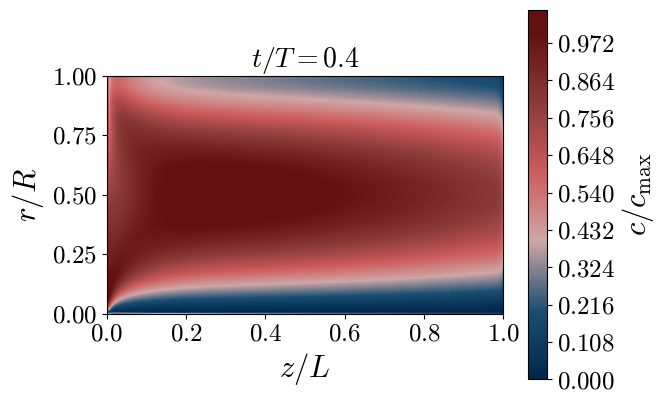

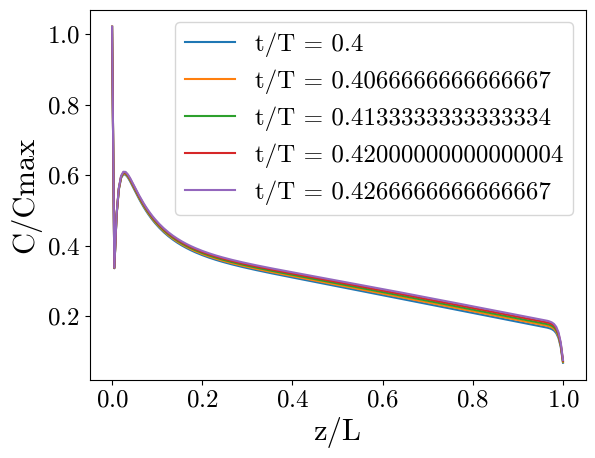

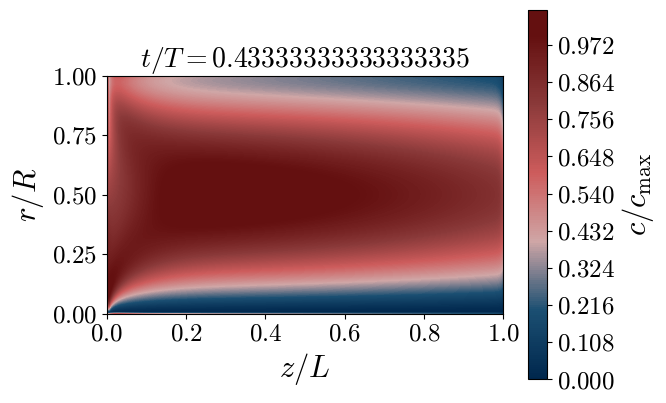

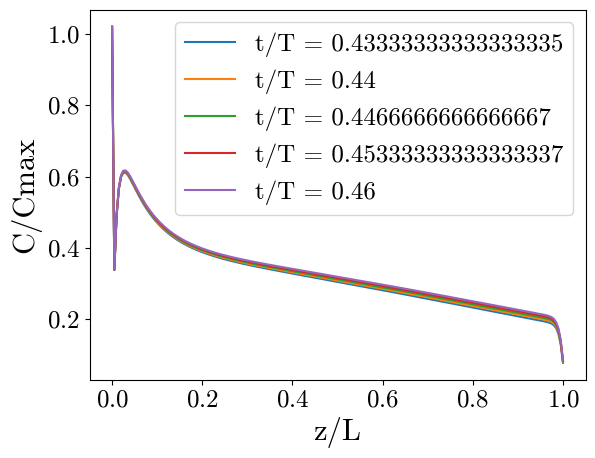

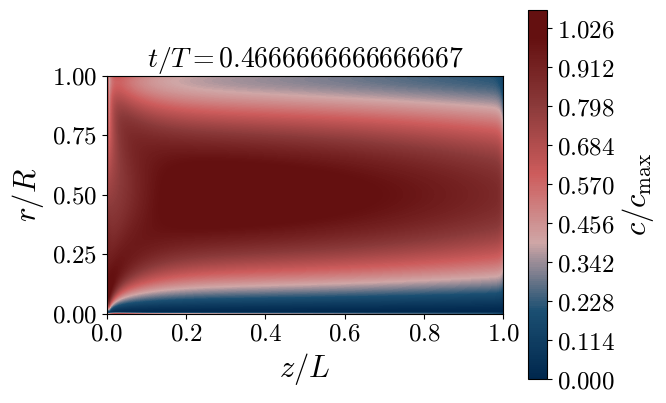

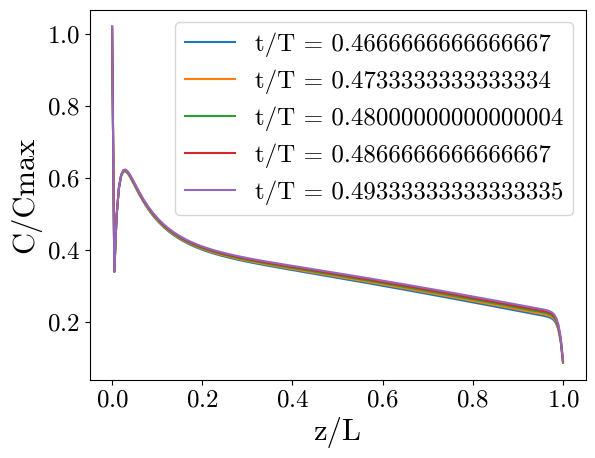

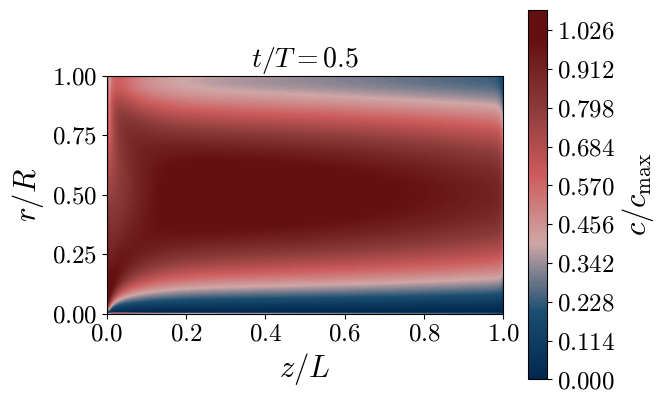

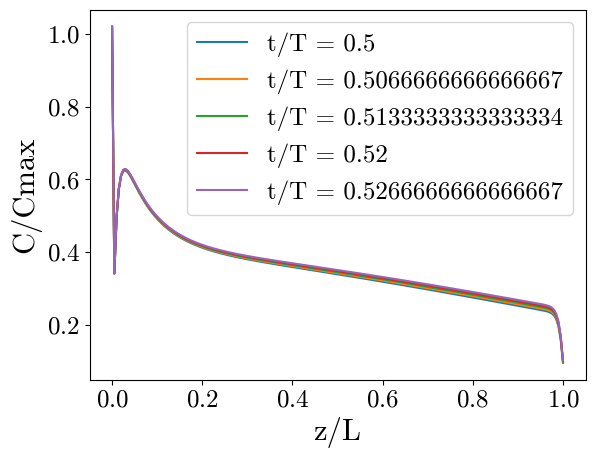

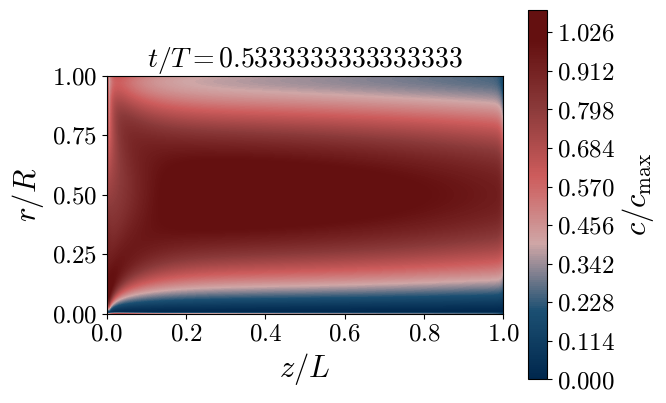

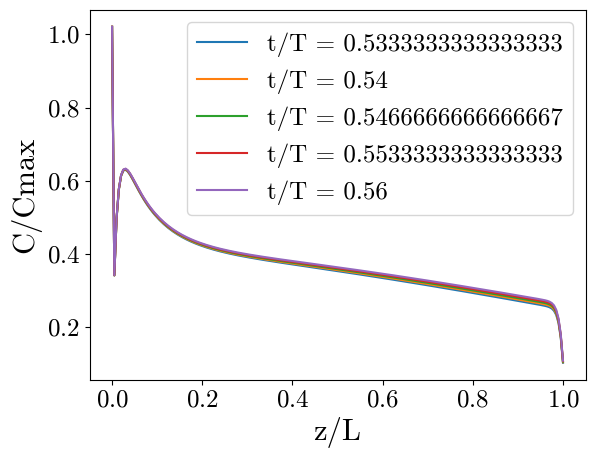

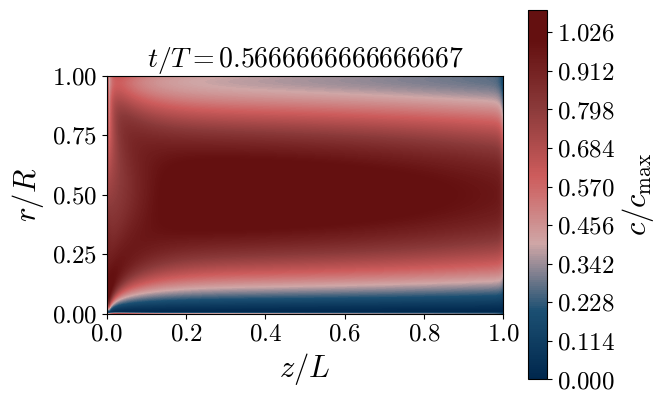

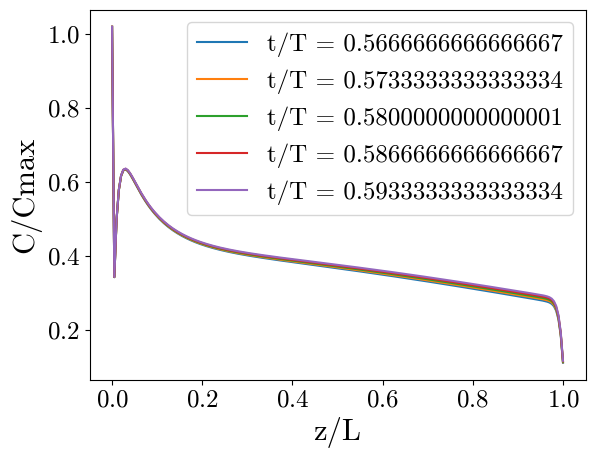

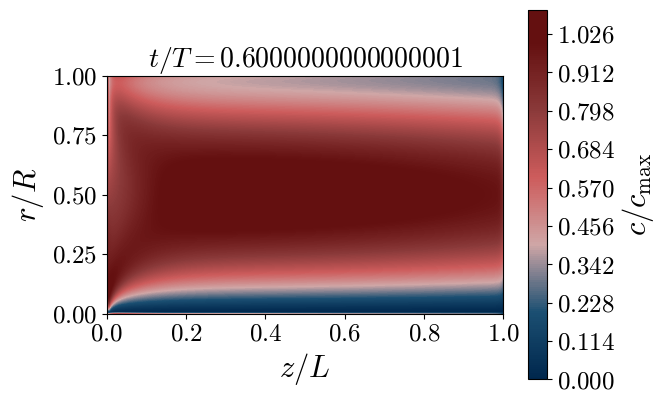

In [ ]:
# Example
BC = (i, e, d)
A = coeff_matrix(M)
C0 = f(ZZ, RR)      # Initial concentration matrix
q0 = np.zeros(M+1)  # Initial wall surface coverage

Ck = C0
qk = q0
plt.figure()
for k, time in enumerate(t):
    g = boundary_vector(grid, k, qk, Ck, BC, M)
    C = concentration_scheme(grid, A, g, k, qk, Ck, BC, M)
    q = RK4(langmuir, qk, C[-1, :])

    if k%5 == 0:
        plt.figure()
        plt.title(f'$t/T = {time}$')
        contour_plot(ZZ, RR, C)
    
    Ck = C
    qk = q
    
    plt.plot(z, Ck[0, :], label=f't/T = {time}')
    plt.xlabel('z/L')
    plt.ylabel('C/Cmax')
    plt.legend()

plt.show()